# 2. Exploratory Data Analysis (EDA) ✅

Comprehensive EDA for recommendation system insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [14]:
# Load processed data from notebook 1
print('Loading processed data...')
df_clean = pd.read_csv(
    '..\\notebooks\\data\\processed\\cleaned_user_products.csv',
    nrows=100000   # 🔥 load only 1 lakh rows
)

user_features = pd.read_csv(
    '..\\notebooks\\data\\processed\\user_features.csv',
    nrows=50000
)

print(f"Clean data: {df_clean.shape}User features: {user_features.shape}")
print('Sample df_clean:\n', df_clean.head(2))

Loading processed data...
Clean data: (100000, 6)User features: (50000, 5)
Sample df_clean:
    user_id  order_id  product_id           product_name  department_id  \
0   202279         2       33120     Organic Egg Whites             16   
1   202279         2       28985  Michigan Organic Kale              4   

   aisle_id  
0        86  
1        83  


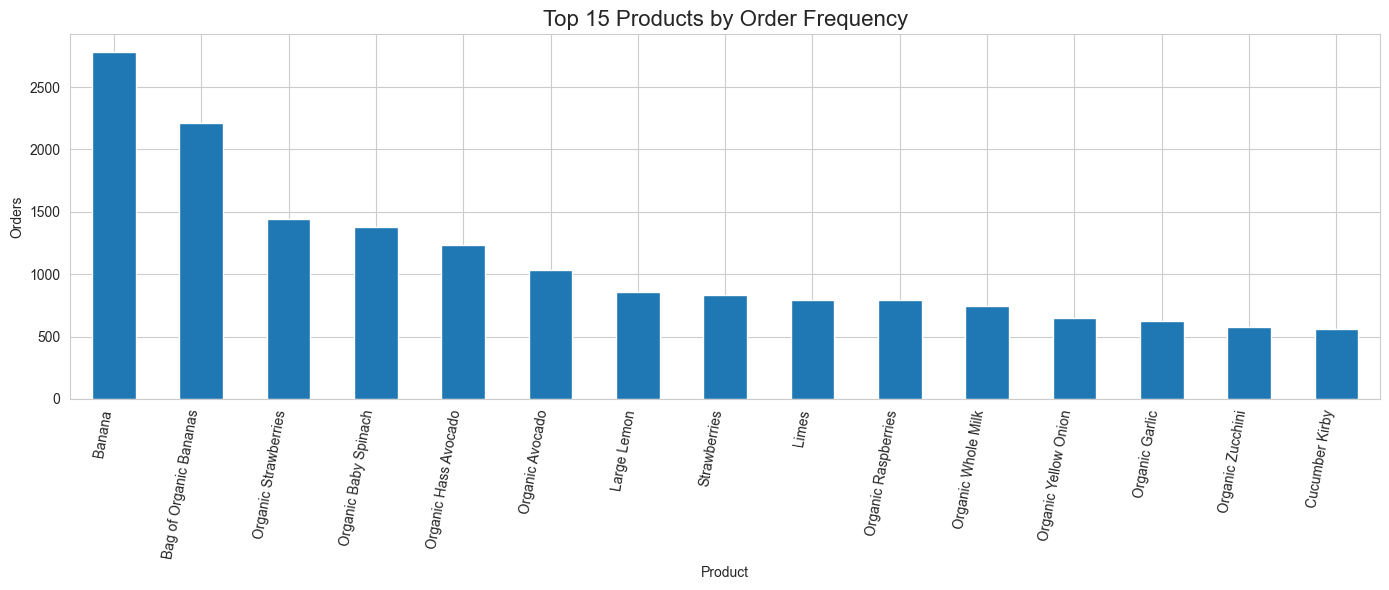

In [15]:
# 1. TOP PRODUCTS
plt.figure(figsize=(14,6))
top_prods = df_clean['product_name'].value_counts().head(15)
top_prods.plot(kind='bar')
plt.title('Top 15 Products by Order Frequency', fontsize=16)
plt.xlabel('Product')
plt.ylabel('Orders')
plt.xticks(rotation=80, ha='right')
plt.tight_layout()
plt.savefig('results/top_products.png', dpi=150)
plt.show()

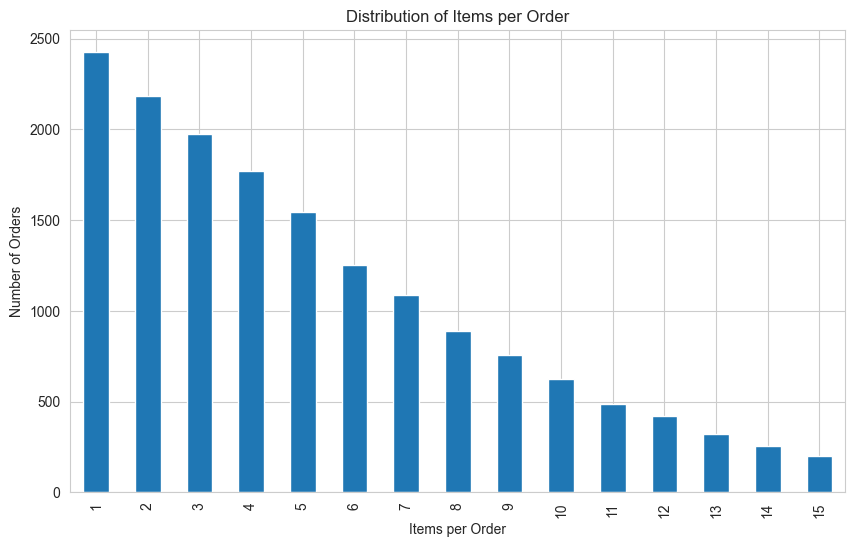

Most common basket sizes: product_id
1    2426
2    2183
3    1976
4    1769
5    1546
Name: count, dtype: int64


In [16]:
# 2. BASKET SIZE ANALYSIS
basket_sizes = df_clean.groupby('order_id')['product_id'].count().value_counts().sort_index()
plt.figure(figsize=(10,6))
basket_sizes.head(15).plot(kind='bar')
plt.title('Distribution of Items per Order')
plt.xlabel('Items per Order')
plt.ylabel('Number of Orders')
plt.savefig('results/basket_sizes.png', dpi=150)
plt.show()
print('Most common basket sizes:', basket_sizes.head())

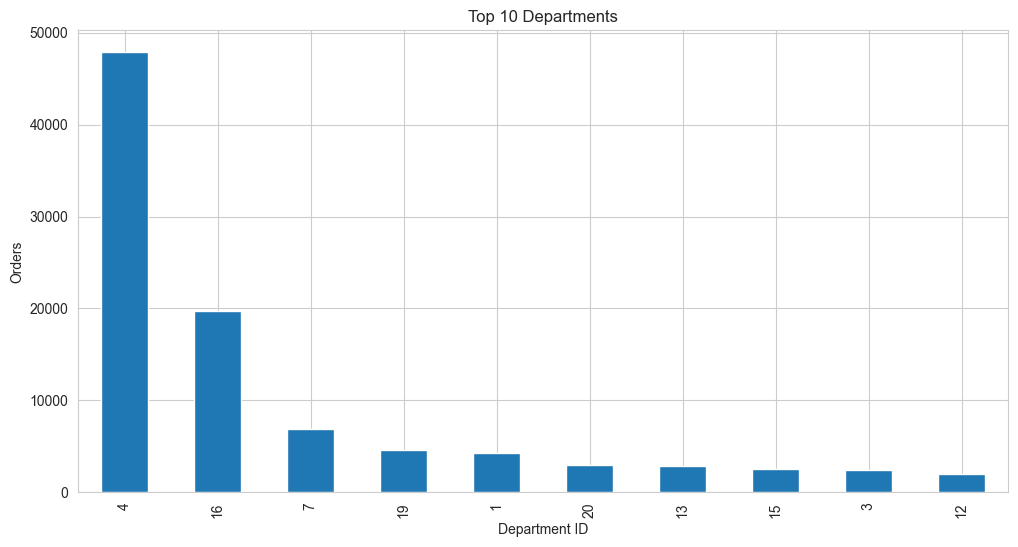

In [17]:
# 3. DEPARTMENT DISTRIBUTION
dept_counts = df_clean['department_id'].value_counts().head(10)
plt.figure(figsize=(12,6))
dept_counts.plot(kind='bar')
plt.title('Top 10 Departments')
plt.xlabel('Department ID')
plt.ylabel('Orders')
plt.savefig('results/top_departments.png', dpi=150)
plt.show()

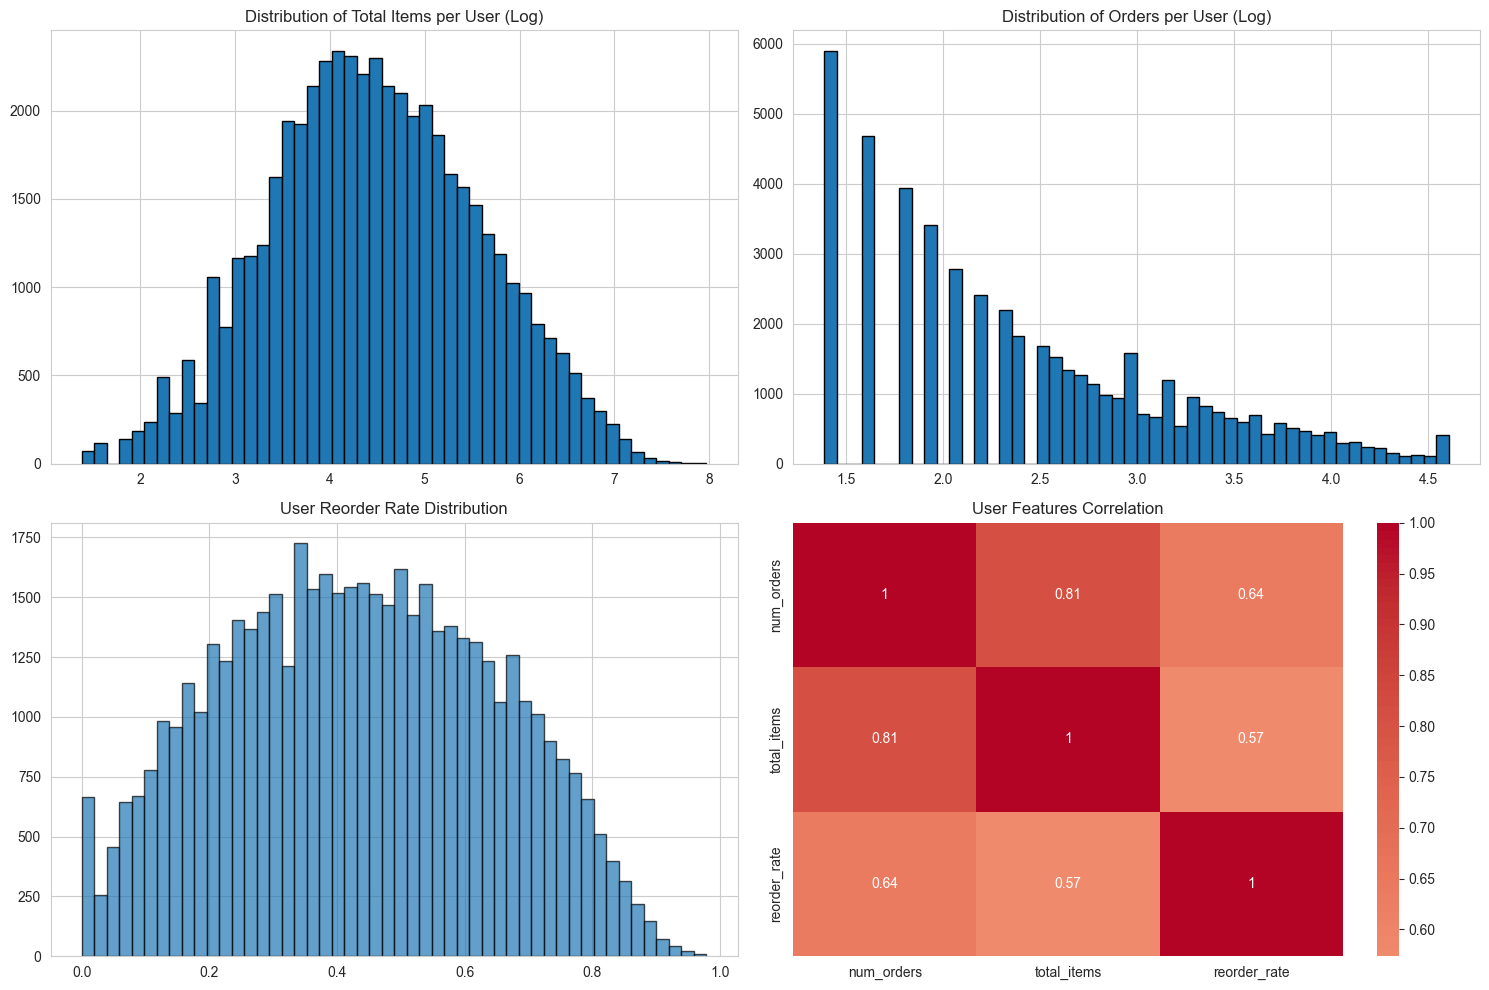

In [18]:
# 4. USER BEHAVIOR ANALYSIS
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Items per user
items_per_user = user_features['total_items'].value_counts().sort_index()
axes[0,0].hist(np.log1p(user_features['total_items']), bins=50, edgecolor='black')
axes[0,0].set_title('Distribution of Total Items per User (Log)')

# Orders per user
axes[0,1].hist(np.log1p(user_features['num_orders']), bins=50, edgecolor='black')
axes[0,1].set_title('Distribution of Orders per User (Log)')

# Reorder rate
axes[1,0].hist(user_features['reorder_rate'], bins=50, edgecolor='black', alpha=0.7)
axes[1,0].set_title('User Reorder Rate Distribution')

# Correlation heatmap
corr = user_features[['num_orders', 'total_items', 'reorder_rate']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('User Features Correlation')

plt.tight_layout()
plt.savefig('results/user_behavior.png', dpi=150)
plt.show()

In [ ]:
# 5. FREQUENT ITEM PAIRS PREVIEW
basket = df_clean.groupby(['order_id', 'product_name'])['product_id'].count().unstack().notnull().astype(int)
print(f'Basket matrix shape: {basket.shape}')

# Top co-occurring products
item_corr = basket.corr().unstack().sort_values(ascending=False)
top_pairs = item_corr[item_corr < 1].dropna().head(10)
print('\nTop 10 co-occurring product pairs:')
print(top_pairs)

Basket matrix shape: (17020, 1000)


## EDA Summary ✅

**Key Insights:**
- Popular products: Bananas, Bag of Organic Bananas dominate
- Typical basket: 4-10 items
- Power users: Heavy tails in user behavior
- Strong department preferences
- Good candidates for association rules

**Saved:** results/top_products.png, basket_sizes.png, top_departments.png, user_behavior.png

**Next:** Notebook 3 - Customer Clustering